**Install Libraries**

In [1]:
!pip install imbalanced-learn xgboost shap --quiet

**Import Libraries**

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, average_precision_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import shap

**Extract File**

In [3]:
if not os.path.exists('creditcard.csv'):
    !unzip /content/creditcard.csv.zip

Archive:  /content/creditcard.csv.zip
  inflating: creditcard.csv          


**Load Data**

In [4]:
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.shape

(284807, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


**Preprocessing**

In [8]:
df.duplicated().sum()

np.int64(1081)

In [9]:
df.drop_duplicates(inplace=True)
print(f'Shape after dropping duplicates: {df.shape}')

Shape after dropping duplicates: (283726, 31)


**EDA**

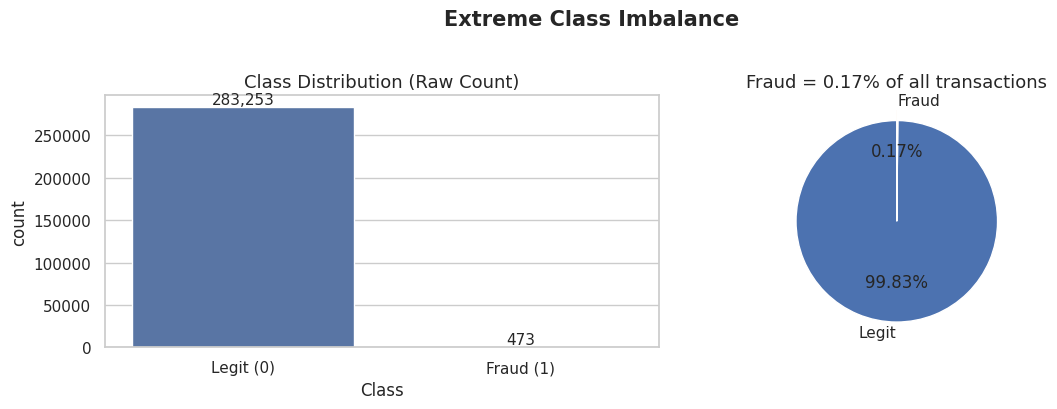

In [10]:
counts = df['Class'].value_counts()
pct_fraud = counts[1] / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='Class', data=df, palette=['#4C72B0', '#DD8452'], ax=axes[0])
axes[0].set_title('Class Distribution (Raw Count)', fontsize=13)
axes[0].set_xticklabels(['Legit (0)', 'Fraud (1)'])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

axes[1].pie([counts[0], counts[1]], labels=['Legit', 'Fraud'],
            autopct='%1.2f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title(f'Fraud = {pct_fraud:.2f}% of all transactions', fontsize=13)

plt.suptitle('Extreme Class Imbalance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

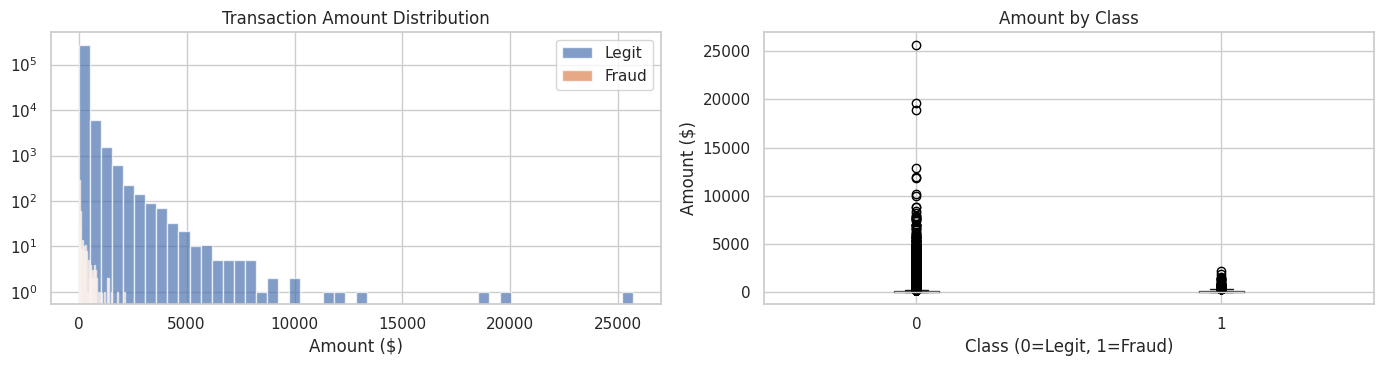

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df['Class'] == 0]['Amount'].hist(bins=50, ax=axes[0], color='#4C72B0', alpha=0.7, label='Legit')
df[df['Class'] == 1]['Amount'].hist(bins=50, ax=axes[0], color='#DD8452', alpha=0.7, label='Fraud')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount ($)')
axes[0].set_yscale('log')
axes[0].legend()

df.boxplot(column='Amount', by='Class', ax=axes[1])
axes[1].set_title('Amount by Class')
axes[1].set_xlabel('Class (0=Legit, 1=Fraud)')
axes[1].set_ylabel('Amount ($)')
plt.suptitle('')

plt.tight_layout()
plt.show()

In [12]:
df.groupby('Class')['Amount'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.41,250.38,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.87,260.21,0.0,1.00,9.82,105.89,2125.87


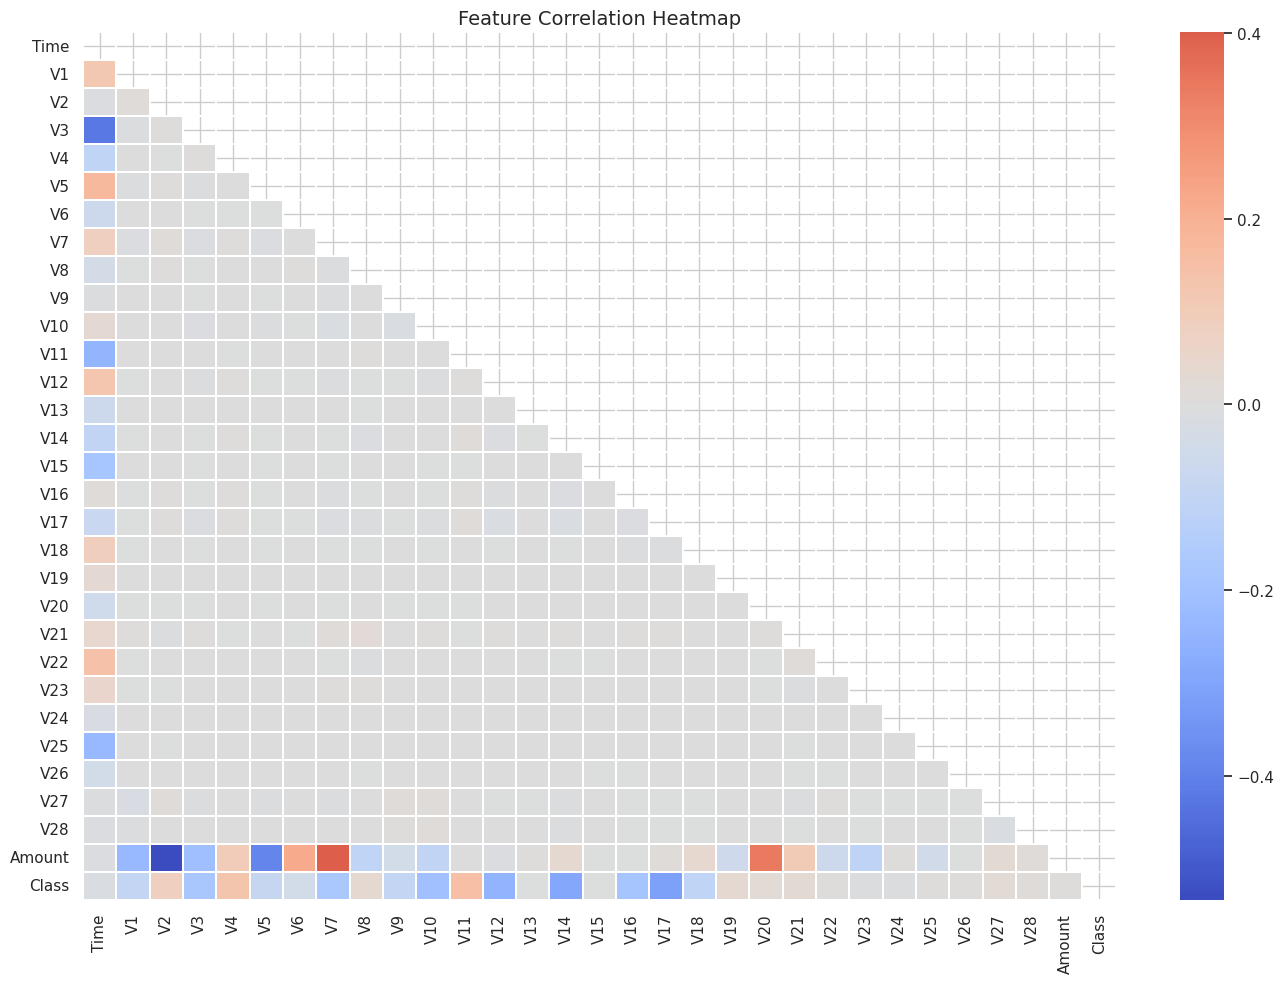

In [13]:
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

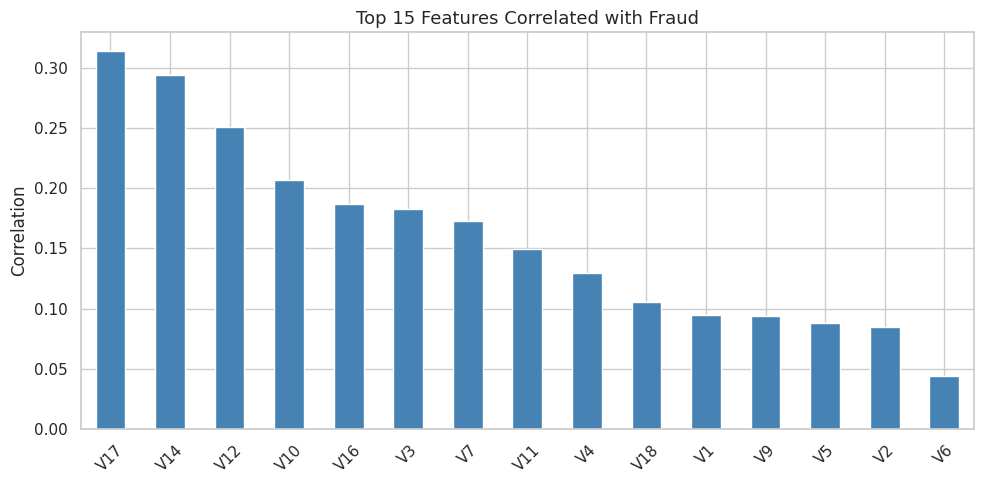

In [14]:
corr_with_class = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
corr_with_class.head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Features Correlated with Fraud', fontsize=13)
plt.ylabel('Correlation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Data Splitting**

In [15]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')
print(f'Fraud in train: {y_train.sum()} | Fraud in test: {y_test.sum()}')

Train size: 226,980 | Test size: 56,746
Fraud in train: 378 | Fraud in test: 95


**Feature Scaling**

In [16]:
scaler = StandardScaler()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

**SMOTE ( Handling Class Imbalance )**

In [17]:
# Visualize SMOTE effect - actual resampling happens inside the pipeline
smote_viz = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote_viz.fit_resample(X_train, y_train)

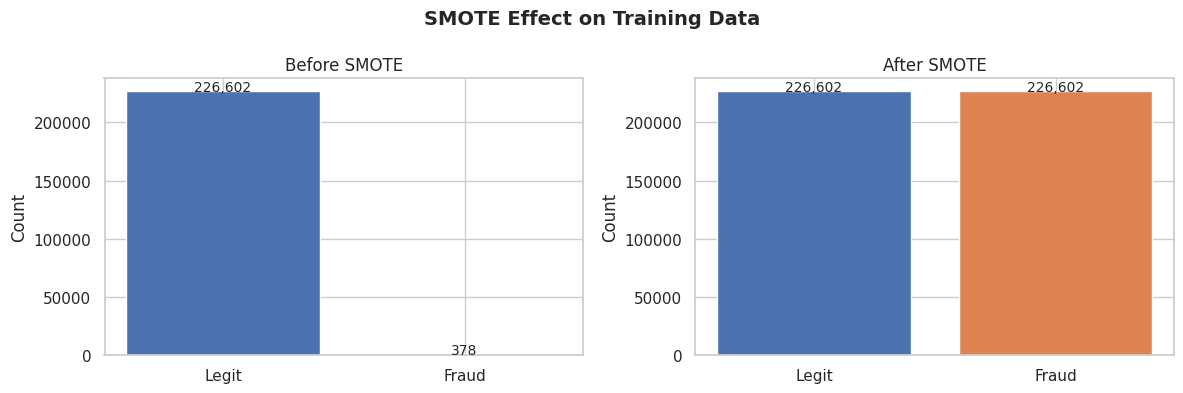

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_data, title in zip(axes, [y_train, y_train_res],
                              ['Before SMOTE', 'After SMOTE']):
    counts = pd.Series(y_data).value_counts()
    ax.bar(['Legit', 'Fraud'], [counts[0], counts[1]],
           color=['#4C72B0', '#DD8452'])
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Count')
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

plt.suptitle('SMOTE Effect on Training Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Models ( Dummy - Logistic Regression - Random Forest - XGBOOST )**

In [19]:
dummy_preds = np.zeros(len(y_test), dtype=int)
dummy_accuracy = (dummy_preds == y_test).mean()
dummy_fraud_recall = 0

print('DUMMY MODEL (predicts 0 for everything)')
print(f'Accuracy:     {dummy_accuracy:.4f}')
print(f'Fraud Recall: {dummy_fraud_recall:.4f}')
print()
print('Lesson: High accuracy means NOTHING on imbalanced data.')
print('Always use: Precision, Recall, F1-Score, AUC-ROC, AUC-PR')

DUMMY MODEL (predicts 0 for everything)
Accuracy:     0.9983
Fraud Recall: 0.0000

Lesson: High accuracy means NOTHING on imbalanced data.
Always use: Precision, Recall, F1-Score, AUC-ROC, AUC-PR


In [20]:
# SMOTE is applied inside each pipeline to prevent data leakage during CV
lr_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

In [21]:
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

In [22]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', xgb.XGBClassifier(
        n_estimators=100,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='aucpr',
        use_label_encoder=False
    ))
])

**Cross Validation**

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': rf_pipeline,
    'XGBoost': xgb_pipeline
}

cv_results = {}

for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores

print(' Cross Validation Results ')
for name, scores in cv_results.items():
    print(f'{name}: {scores.mean():.4f} ± {scores.std():.4f}')

 Cross Validation Results 
Logistic Regression: 0.9807 ± 0.0079
Random Forest: 0.9713 ± 0.0112
XGBoost: 0.9655 ± 0.0134


In [25]:
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    print(f'{name} fitted ✅')

Logistic Regression fitted ✅
Random Forest fitted ✅
XGBoost fitted ✅


**Overfitting Check**

In [26]:
print('Overfitting Check (Train vs Test AUC-ROC) \n')

for name, pipeline in models.items():
    train_score = roc_auc_score(y_train, pipeline.predict_proba(X_train)[:, 1])
    test_score  = roc_auc_score(y_test,  pipeline.predict_proba(X_test)[:, 1])
    diff        = train_score - test_score
    status      = '✅ OK' if diff < 0.05 else '⚠️ Overfit'

    print(f'{name}:')
    print(f'  Train AUC: {train_score:.4f}')
    print(f'  Test  AUC: {test_score:.4f}')
    print(f'  Gap:       {diff:.4f}  {status}')
    print()

Overfitting Check (Train vs Test AUC-ROC) 

Logistic Regression:
  Train AUC: 0.9897
  Test  AUC: 0.9619
  Gap:       0.0278  ✅ OK

Random Forest:
  Train AUC: 1.0000
  Test  AUC: 0.9656
  Gap:       0.0344  ✅ OK

XGBoost:
  Train AUC: 1.0000
  Test  AUC: 0.9495
  Gap:       0.0505  ⚠️ Overfit



**Evaluation**

In [27]:
def evaluate_model(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    print()
    print(f'  {name}')
    print(classification_report(y_test, y_pred,
                                 target_names=['Legit', 'Fraud']))

    auc_roc = roc_auc_score(y_test, y_prob)
    auc_pr  = average_precision_score(y_test, y_prob)
    print(f'AUC-ROC : {auc_roc:.4f}')
    print(f'AUC-PR  : {auc_pr:.4f}')

    return y_pred, y_prob

results = {}
for name, pipeline in models.items():
    y_pred, y_prob = evaluate_model(name, pipeline, X_test, y_test)
    results[name] = {'y_pred': y_pred, 'y_prob': y_prob}


  Logistic Regression
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

AUC-ROC : 0.9619
AUC-PR  : 0.6769

  Random Forest
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.91      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746

AUC-ROC : 0.9656
AUC-PR  : 0.8038

  XGBoost
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.54      0.81      0.65        95

    accuracy                           1.00     56746
   macro 

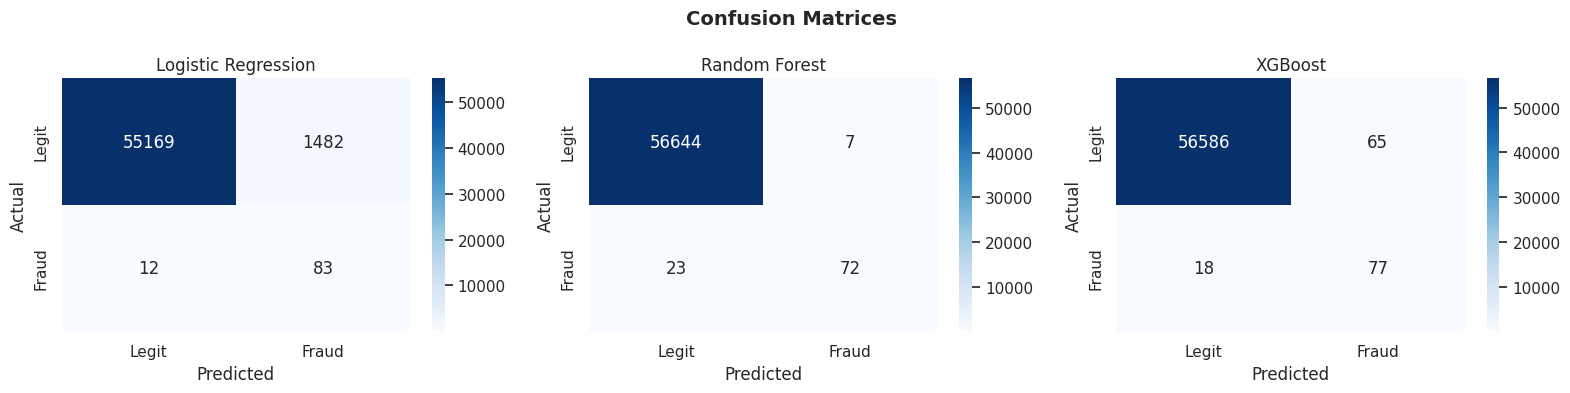

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'])
    ax.set_title(name, fontsize=12)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

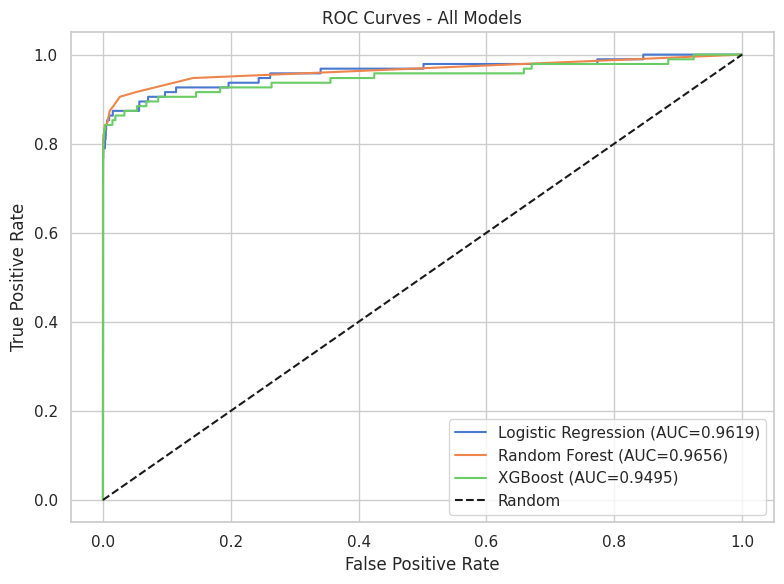

In [29]:
plt.figure(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = roc_auc_score(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend()
plt.tight_layout()
plt.show()

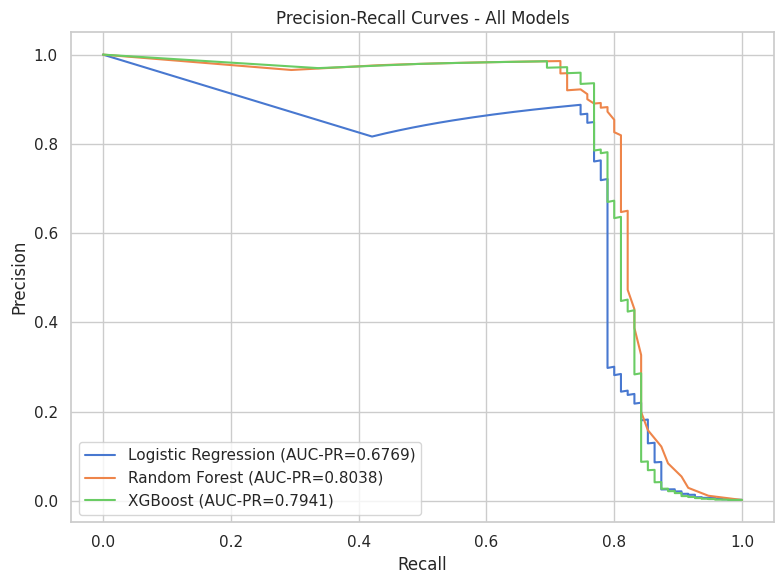

In [30]:
plt.figure(figsize=(8, 6))

for name, res in results.items():
    precision, recall, _ = precision_recall_curve(y_test, res['y_prob'])
    auc_pr = average_precision_score(y_test, res['y_prob'])
    plt.plot(recall, precision, label=f'{name} (AUC-PR={auc_pr:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - All Models')
plt.legend()
plt.tight_layout()
plt.show()

**SHAP Analysis**

In [31]:
rf_model = models['Random Forest'].named_steps['model']

X_test_sample = X_test.sample(500, random_state=42)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_sample)

# Shape (500, 30, 2) → [:, :, 1] = Fraud class
shap_fraud = shap_values[:, :, 1]
print(f'SHAP values shape: {shap_fraud.shape}')

SHAP values shape: (500, 30)


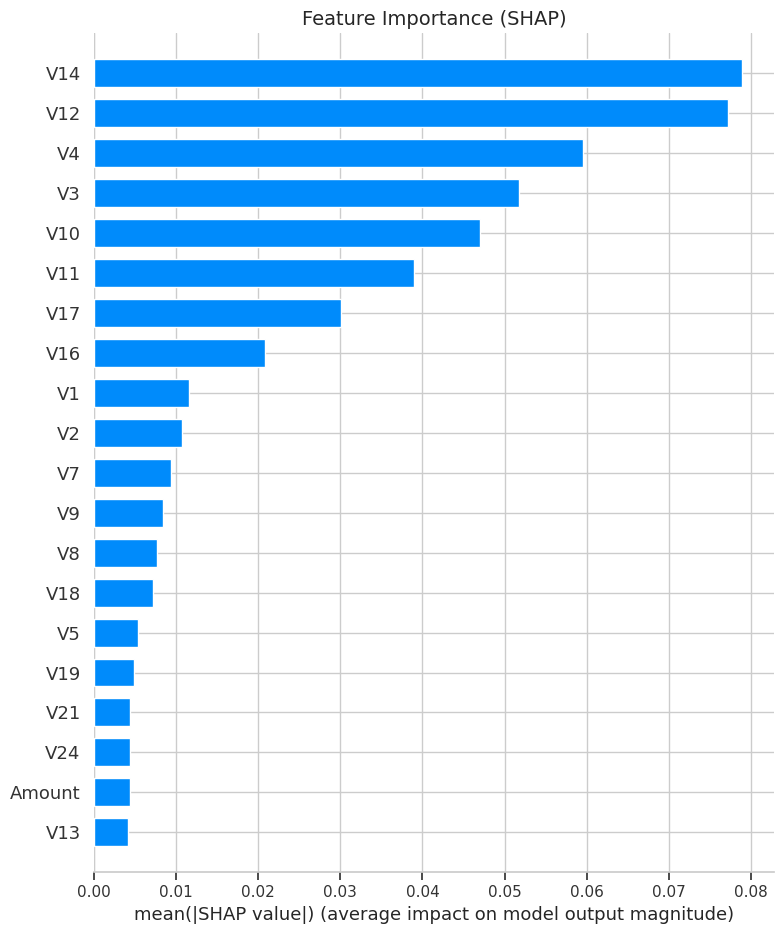

In [32]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_fraud, X_test_sample,
                  plot_type='bar',
                  show=False)
plt.title('Feature Importance (SHAP)', fontsize=14)
plt.tight_layout()
plt.show()

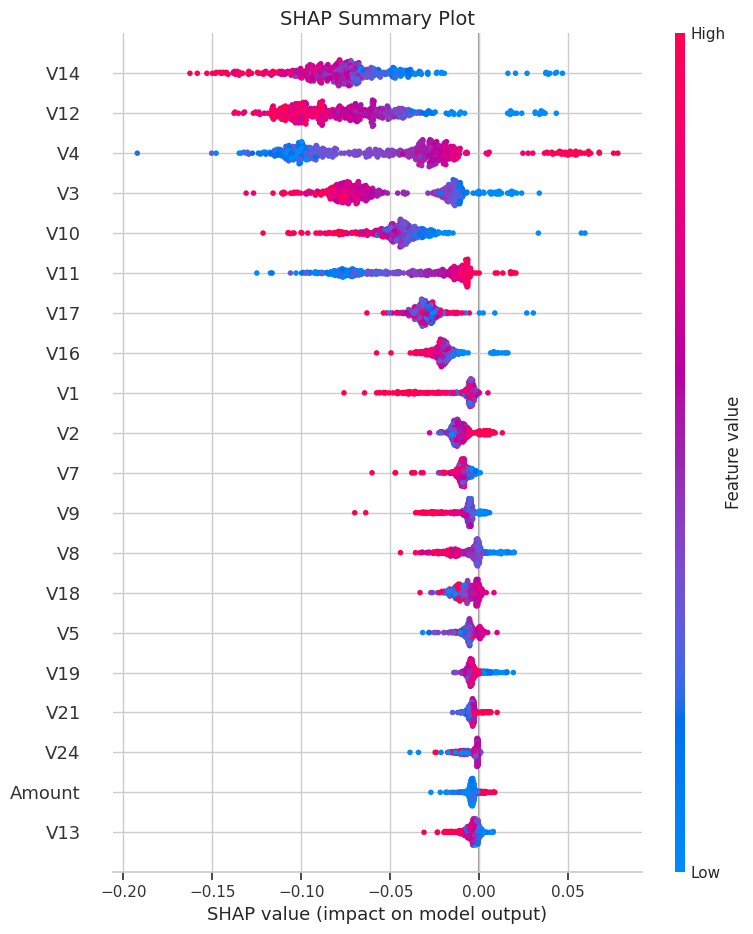

In [33]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_fraud, X_test_sample,
                  show=False)
plt.title('SHAP Summary Plot', fontsize=14)
plt.tight_layout()
plt.show()

Transaction index: 116139
Model probability: 0.9900


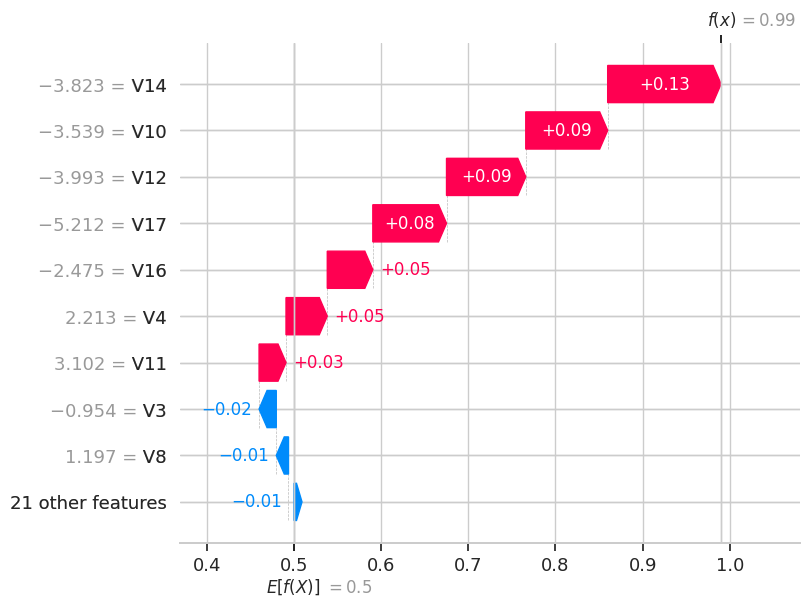

In [34]:
# Get first fraud case directly from X_test
fraud_indices = y_test[y_test == 1].index.tolist()
first_fraud_idx = fraud_indices[0]
first_fraud = X_test.loc[[first_fraud_idx]]

shap_single = explainer.shap_values(first_fraud)
shap_single_fraud = shap_single[:, :, 1][0]

print(f'Transaction index: {first_fraud_idx}')
print(f'Model probability: {models["Random Forest"].predict_proba(first_fraud)[0][1]:.4f}')

shap.waterfall_plot(
    shap.Explanation(
        values=shap_single_fraud,
        base_values=explainer.expected_value[1],
        data=first_fraud.values[0],
        feature_names=X_test.columns.tolist()
    )
)

**Threshold Tuning**

In [35]:
y_prob_rf = results['Random Forest']['y_prob']

thresholds = np.arange(0.1, 0.9, 0.05)

precision_scores = []
recall_scores = []
f1_scores = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_rf >= thresh).astype(int)

    tp = ((y_pred_thresh == 1) & (y_test == 1)).sum()
    fp = ((y_pred_thresh == 1) & (y_test == 0)).sum()
    fn = ((y_pred_thresh == 0) & (y_test == 1)).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

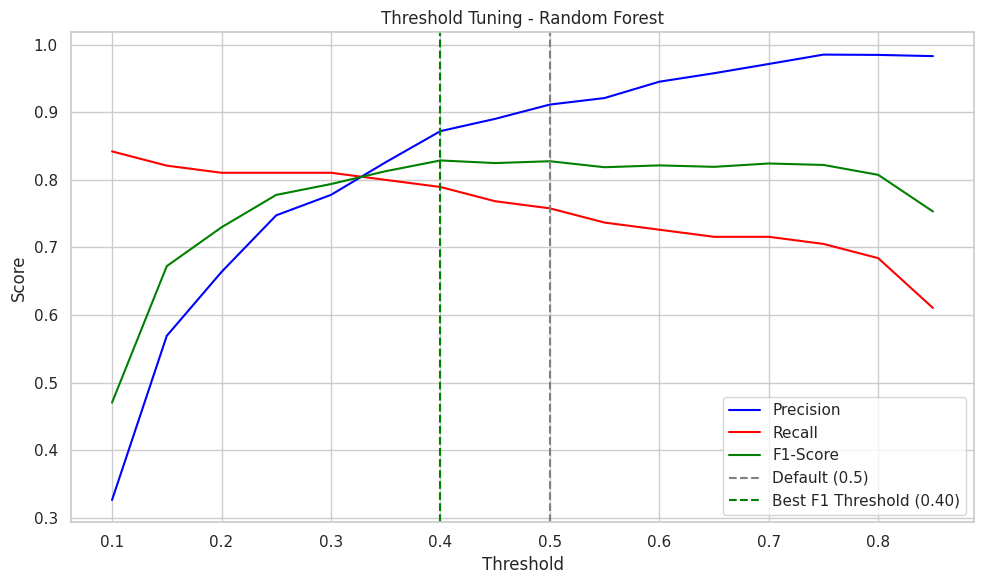

Best Threshold : 0.40
Precision      : 0.8721
Recall         : 0.7895
F1-Score       : 0.8287

--- Comparison ---
Default (0.5)  -> Precision: 0.9114 | Recall: 0.7579
Best Threshold -> Precision: 0.8721 | Recall: 0.7895


In [36]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision_scores, label='Precision', color='blue')
plt.plot(thresholds, recall_scores,    label='Recall',    color='red')
plt.plot(thresholds, f1_scores,        label='F1-Score',  color='green')

plt.axvline(x=0.5, color='gray', linestyle='--', label='Default (0.5)')

best_thresh = thresholds[np.argmax(f1_scores)]
plt.axvline(x=best_thresh, color='green', linestyle='--',
            label=f'Best F1 Threshold ({best_thresh:.2f})')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning - Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

best_f1_idx = np.argmax(f1_scores)
print(f'Best Threshold : {thresholds[best_f1_idx]:.2f}')
print(f'Precision      : {precision_scores[best_f1_idx]:.4f}')
print(f'Recall         : {recall_scores[best_f1_idx]:.4f}')
print(f'F1-Score       : {f1_scores[best_f1_idx]:.4f}')
print('\n--- Comparison ---')
print(f'Default (0.5)  -> Precision: {precision_scores[8]:.4f} | Recall: {recall_scores[8]:.4f}')
print(f'Best Threshold -> Precision: {precision_scores[best_f1_idx]:.4f} | Recall: {recall_scores[best_f1_idx]:.4f}')

**Final Comparison Dashboard**

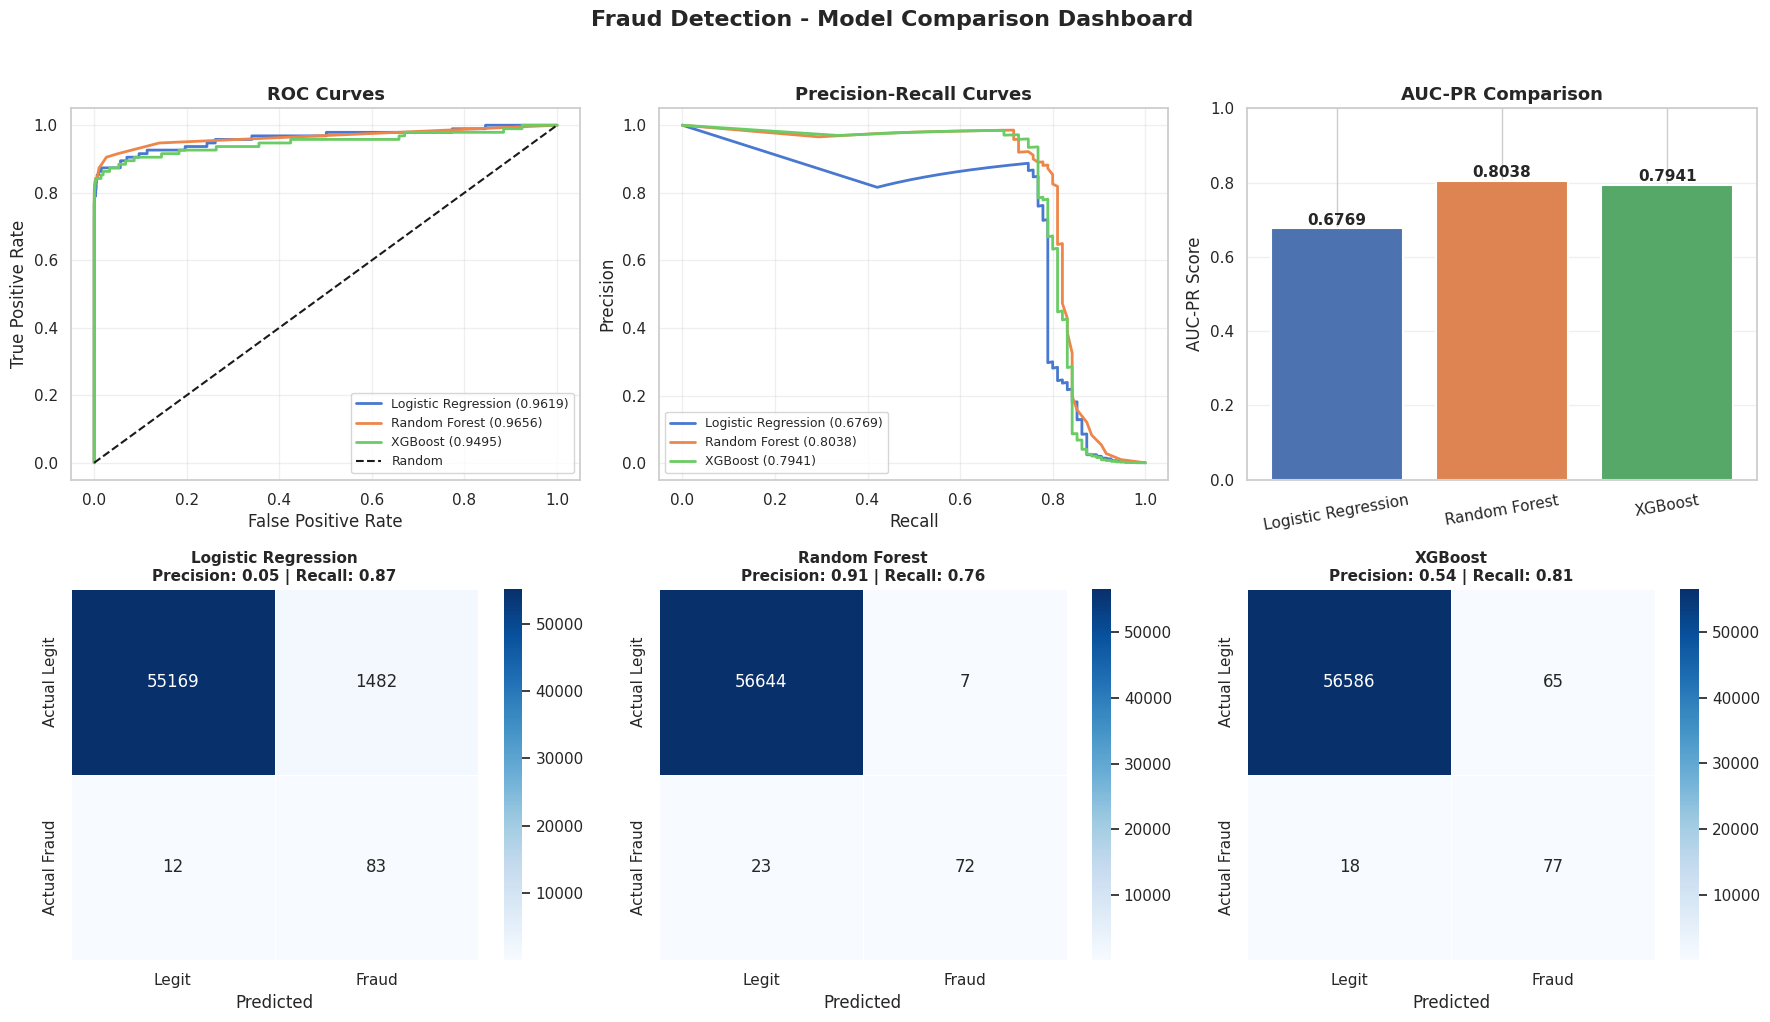

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Fraud Detection - Model Comparison Dashboard',
             fontsize=16, fontweight='bold', y=1.02)

# --- Plot 1: AUC-ROC Curves ---
ax = axes[0, 0]
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = roc_auc_score(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f'{name} ({auc:.4f})', linewidth=2)
ax.plot([0,1], [0,1], 'k--', label='Random')
ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 2: Precision-Recall Curves ---
ax = axes[0, 1]
for name, res in results.items():
    precision, recall, _ = precision_recall_curve(y_test, res['y_prob'])
    auc_pr = average_precision_score(y_test, res['y_prob'])
    ax.plot(recall, precision, label=f'{name} ({auc_pr:.4f})', linewidth=2)
ax.set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 3: AUC-PR Bar Chart ---
ax = axes[0, 2]
names = list(results.keys())
auc_pr_scores = [average_precision_score(y_test, results[n]['y_prob']) for n in names]
colors = ['#4C72B0', '#DD8452', '#55A868']
bars = ax.bar(names, auc_pr_scores, color=colors, edgecolor='white', linewidth=1.5)
ax.set_title('AUC-PR Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('AUC-PR Score')
ax.set_ylim(0, 1)
for bar, score in zip(bars, auc_pr_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticklabels(names, rotation=10)

# --- Plot 4,5,6: Confusion Matrices ---
for idx, (name, res) in enumerate(results.items()):
    ax = axes[1, idx]
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=0.5)

    recall_fraud = cm[1,1] / (cm[1,0] + cm[1,1])
    precision_fraud = cm[1,1] / (cm[0,1] + cm[1,1]) if (cm[0,1] + cm[1,1]) > 0 else 0

    ax.set_title(f'{name}\nPrecision: {precision_fraud:.2f} | Recall: {recall_fraud:.2f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('model_comparison_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

**Save Model**

In [38]:
import joblib
joblib.dump(models['Random Forest'], 'fraud_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('Saved ✅')

Saved ✅
